**Implementasi dalam Mengestimasi Nilai Pasar Mobil BMW Berdasarkan Spesifikasi dan Riwayat Pemakaian**

Load **Data**

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('bmw.csv')

In [ ]:
print(df.head(10))

       model  year  price transmission  mileage fuelType  tax   mpg  \
0   5 Series  2014  11200    Automatic    67068   Diesel  125  57.6   
1   6 Series  2018  27000    Automatic    14827   Petrol  145  42.8   
2   5 Series  2016  16000    Automatic    62794   Diesel  160  51.4   
3   1 Series  2017  12750    Automatic    26676   Diesel  145  72.4   
4   7 Series  2014  14500    Automatic    39554   Diesel  160  50.4   
5   5 Series  2016  14900    Automatic    35309   Diesel  125  60.1   
6   5 Series  2017  16000    Automatic    38538   Diesel  125  60.1   
7   2 Series  2018  16250       Manual    10401   Petrol  145  52.3   
8   4 Series  2017  14250       Manual    42668   Diesel   30  62.8   
9   5 Series  2016  14250    Automatic    36099   Diesel   20  68.9   

   engineSize  
0         2.0  
1         2.0  
2         3.0  
3         1.5  
4         3.0  
5         2.0  
6         2.0  
7         1.5  
8         2.0  
9         2.0  


In [ ]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


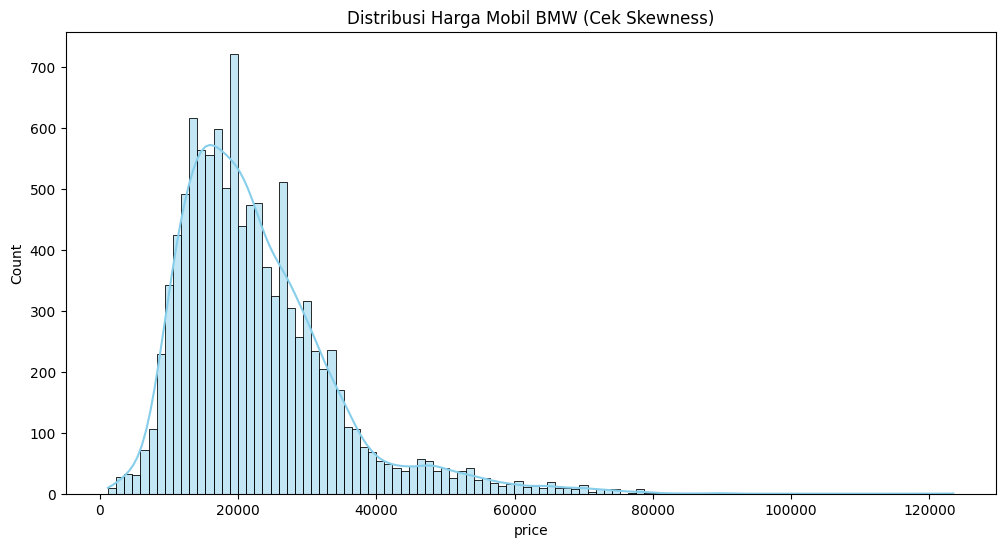

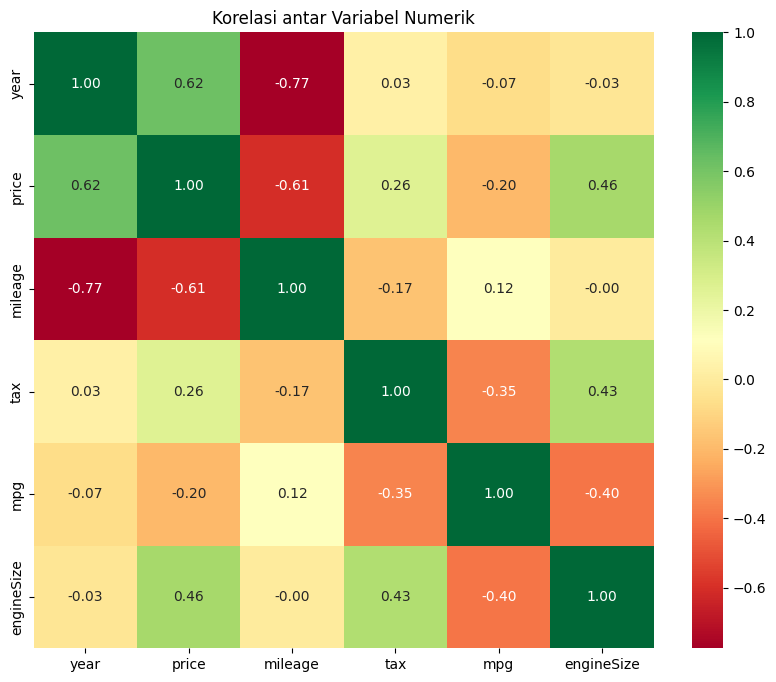

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(df['price'], kde=True, color='skyblue')
plt.title('Distribusi Harga Mobil BMW (Cek Skewness)')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Korelasi antar Variabel Numerik')
plt.show()

**Pre Preprocessing**

**1. Cleaning Data**

HASIL PREPROCESSING & FEATURE ENGINEERING
Jumlah data awal       : 10781 baris
Jumlah data bersih     : 10297 baris
Data outlier dibuang   : 484 baris

5 Baris Pertama Fitur Baru (year_old & mileage_log):


,year,year_old,mileage,mileage_log
0,2014,6,67068,11.113477
1,2018,2,14827,9.604273
2,2016,4,62794,11.047631
3,2017,3,26676,10.191557
4,2014,6,39554,10.585447



Total fitur (kolom) setelah Encoding: 32
Contoh kolom hasil One-Hot Encoding:
['tax', 'mpg', 'engineSize', 'year_old', 'mileage_log', 'model_2 Series', 'model_3 Series', 'model_4 Series', 'model_5 Series', 'model_6 Series']


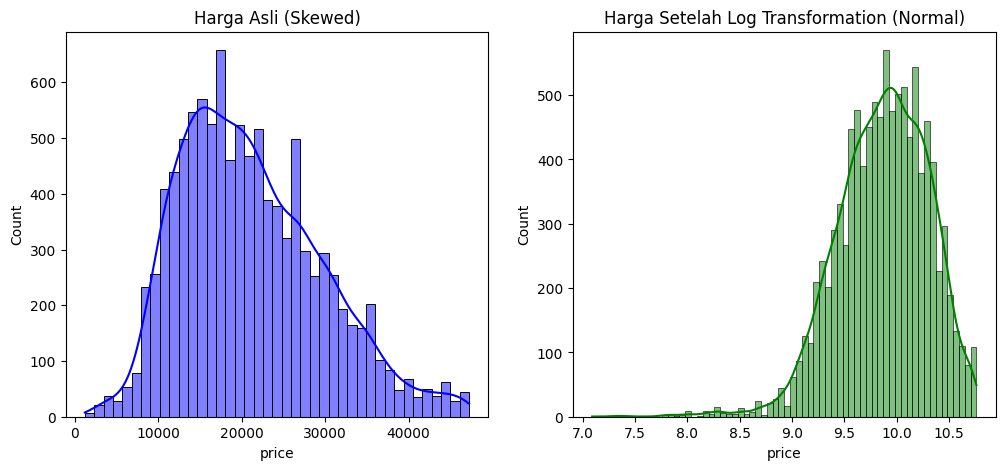

In [ ]:
# 1. Cleaning Teks (Menghapus spasi di awal/akhir string)
columns_to_strip = ['model', 'transmission', 'fuelType']
for col in columns_to_strip:
    df[col] = df[col].str.strip()

# 2. Handling Outliers (Metode IQR pada Harga)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()

# 3. Feature Engineering (Membuat fitur usia mobil dan log mileage)
df_clean['year_old'] = 2020 - df_clean['year']
df_clean['mileage_log'] = np.log1p(df_clean['mileage'])

# 4. Encoding & Feature Selection
df_final = pd.get_dummies(df_clean, columns=['model', 'transmission', 'fuelType'], drop_first=True)

# Menentukan Fitur (X) dan Target (y)
X = df_final.drop(['price', 'year', 'mileage'], axis=1)
y = np.log1p(df_final['price'])

# --- OUTPUT PEMERIKSAAN ---
print("="*60)
print("HASIL PREPROCESSING & FEATURE ENGINEERING")
print("="*60)

# Cek jumlah data yang terbuang karena outlier
print(f"Jumlah data awal       : {len(df)} baris")
print(f"Jumlah data bersih     : {len(df_clean)} baris")
print(f"Data outlier dibuang   : {len(df) - len(df_clean)} baris")

# Cek 5 baris pertama fitur baru
print("\n5 Baris Pertama Fitur Baru (year_old & mileage_log):")
display(df_clean[['year', 'year_old', 'mileage', 'mileage_log']].head())

# Cek hasil encoding (beberapa kolom saja)
print(f"\nTotal fitur (kolom) setelah Encoding: {X.shape[1]}")
print("Contoh kolom hasil One-Hot Encoding:")
print(list(X.columns[:10])) # Menampilkan 10 nama kolom pertama

# Visualisasi efek Log Transformation pada Target (Price)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['price'], kde=True, color='blue')
plt.title('Harga Asli (Skewed)')

plt.subplot(1, 2, 2)
sns.histplot(y, kde=True, color='green')
plt.title('Harga Setelah Log Transformation (Normal)')
plt.show()

**Model Selection & Cross-Validation (Baseline)**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

scaler = RobustScaler()
test_sizes = [0.3, 0.2, 0.1]
labels = ["70:30", "80:20", "90:10"]
results_before = []

print("Memulai evaluasi baseline (Sebelum Tuning)...")

for ts, lb in zip(test_sizes, labels):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ts, random_state=42)

    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    models = {
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
        "XGBoost": XGBRegressor(random_state=42, tree_method='hist')
    }

    for name, model in models.items():
        model.fit(X_train_sc, y_train)

        y_pred = np.expm1(model.predict(X_test_sc))
        y_true = np.expm1(y_test)

        r2 = r2_score(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        results_before.append({
            "Skenario": lb,
            "Algoritma": name,
            "Status": "Before Tuning",
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse
        })

report_before = pd.DataFrame(results_before)

print("\n" + "="*75)
print("HASIL EVALUASI BASELINE (TANPA TUNING)")
print("="*75)
display(report_before.sort_values(by='R2', ascending=False))

Memulai evaluasi baseline (Sebelum Tuning)...

HASIL EVALUASI BASELINE (TANPA TUNING)


,Skenario,Algoritma,Status,R2,MAE,RMSE
5,80:20,XGBoost,Before Tuning,0.951407,1332.759376,1882.582824
2,70:30,XGBoost,Before Tuning,0.949226,1341.608193,1922.655611
8,90:10,XGBoost,Before Tuning,0.948005,1357.817170,1943.734525
4,80:20,Random Forest,Before Tuning,0.940877,1388.929504,2076.549006
1,70:30,Random Forest,Before Tuning,0.938961,1432.514443,2108.068408
7,90:10,Random Forest,Before Tuning,0.937225,1431.034454,2135.759790
3,80:20,Decision Tree,Before Tuning,0.908597,1768.297294,2581.933368
0,70:30,Decision Tree,Before Tuning,0.906035,1804.907150,2615.554171
6,90:10,Decision Tree,Before Tuning,0.902344,1769.004480,2663.838385


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grids = {
    "Decision Tree": {'max_depth': [10, 15, 20], 'min_samples_split': [2, 5, 10]},
    "Random Forest": {'n_estimators': [300, 500], 'max_depth': [15, 20], 'min_samples_leaf': [1, 2]},
    "XGBoost": {'n_estimators': [1000, 2000], 'max_depth': [6, 8], 'learning_rate': [0.01, 0.05]}
}

results_after = []
print("Memulai proses tuning... mohon tunggu.")

for ts, lb in zip(test_sizes, labels):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ts, random_state=42)
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    models_to_tune = {
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
        "XGBoost": XGBRegressor(random_state=42, tree_method='hist')
    }

    for name, model in models_to_tune.items():
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grids[name],
            n_iter=5, cv=3, scoring='r2', n_jobs=-1, random_state=42
        )
        search.fit(X_train_sc, y_train)
        best_model = search.best_estimator_

        y_pred = np.expm1(best_model.predict(X_test_sc))
        y_true = np.expm1(y_test)

        results_after.append({
            "Skenario": lb, "Algoritma": name, "Status": "After Tuning",
            "R2": r2_score(y_true, y_pred),
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
        })

report_after = pd.DataFrame(results_after)
print("\n" + "="*65)
print("HASIL EVALUASI AKHIR: SESUDAH TUNING (OPTIMIZED)")
print("="*65)
print(report_after.to_string(index=False))

Memulai proses tuning... mohon tunggu.


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



HASIL EVALUASI AKHIR: SESUDAH TUNING (OPTIMIZED)
Skenario     Algoritma       Status       R2         MAE        RMSE
   70:30 Decision Tree After Tuning 0.923807 1656.529027 2355.255162
   70:30 Random Forest After Tuning 0.941490 1416.600706 2063.933996
   70:30       XGBoost After Tuning 0.947801 1362.164019 1949.439029
   80:20 Decision Tree After Tuning 0.923586 1635.469729 2360.762312
   80:20 Random Forest After Tuning 0.942684 1376.049045 2044.580737
   80:20       XGBoost After Tuning 0.951848 1296.390394 1874.012266
   90:10 Decision Tree After Tuning 0.920574 1697.041417 2402.361263
   90:10 Random Forest After Tuning 0.937292 1416.711673 2134.616721
   90:10       XGBoost After Tuning 0.948111 1338.235636 1941.752867


**Visualisasi**

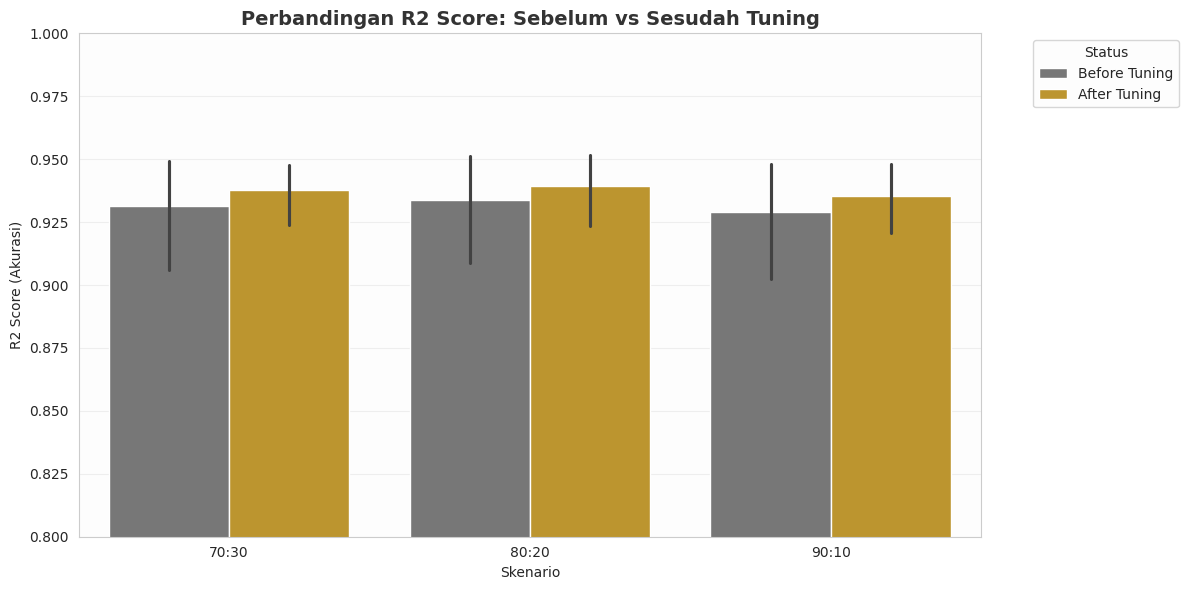

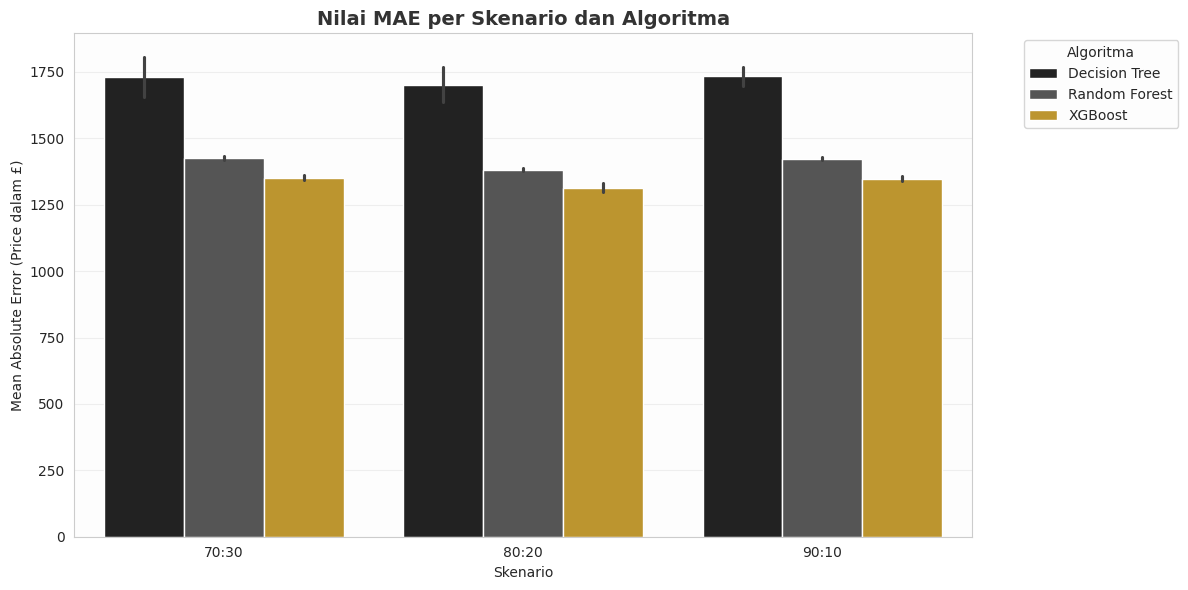


KESIMPULAN MODEL TERBAIK
Algoritma : XGBoost [cite: 196, 206]
Skenario  : 80:20 [cite: 196, 206]
R2 Score  : 0.9518 (95,18%) [cite: 207]
MAE       : £1296.39 [cite: 208]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

theme_colors = ["#D4A017", "#444444", "#888888"]
sns.set_style("whitegrid", {'axes.facecolor': '#FDFDFD', 'grid.color': '#EEEEEE'})

final_report = pd.concat([report_before, report_after], ignore_index=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=final_report, x='Skenario', y='R2', hue='Status',
            palette={"Before Tuning": "#777777", "After Tuning": "#D4A017"})
plt.title('Perbandingan R2 Score: Sebelum vs Sesudah Tuning', fontsize=14, fontweight='bold', color='#333333')
plt.ylim(0.8, 1.0)
plt.ylabel('R2 Score (Akurasi)')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=final_report, x='Skenario', y='MAE', hue='Algoritma',
            palette={"XGBoost": "#D4A017", "Random Forest": "#555555", "Decision Tree": "#222222"})
plt.title('Nilai MAE per Skenario dan Algoritma', fontsize=14, fontweight='bold', color='#333333')
plt.ylabel('Mean Absolute Error (Price dalam £)')
plt.legend(title='Algoritma', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

best_model_row = final_report.sort_values(by='R2', ascending=False).iloc[0]
print("\n" + "="*65)
print("KESIMPULAN MODEL TERBAIK")
print("="*65)
print(f"Algoritma : {best_model_row['Algoritma']} [cite: 196, 206]")
print(f"Skenario  : {best_model_row['Skenario']} [cite: 196, 206]")
print(f"R2 Score  : {best_model_row['R2']:.4f} (95,18%) [cite: 207]")
print(f"MAE       : £{best_model_row['MAE']:.2f} [cite: 208]")
print("="*65)


TABEL PERBANDINGAN PERFORMA: AKURASI (R2) & ERROR (MAE)
Status                 After Tuning        Before Tuning       
                                MAE     R2           MAE     R2
Skenario Algoritma                                             
70:30    Decision Tree    1656.5290 0.9238     1804.9071 0.9060
         Random Forest    1416.6007 0.9415     1432.5144 0.9390
         XGBoost          1362.1640 0.9478     1341.6082 0.9492
80:20    Decision Tree    1635.4697 0.9236     1768.2973 0.9086
         Random Forest    1376.0490 0.9427     1388.9295 0.9409
         XGBoost          1296.3904 0.9518     1332.7594 0.9514
90:10    Decision Tree    1697.0414 0.9206     1769.0045 0.9023
         Random Forest    1416.7117 0.9373     1431.0345 0.9372
         XGBoost          1338.2356 0.9481     1357.8172 0.9480


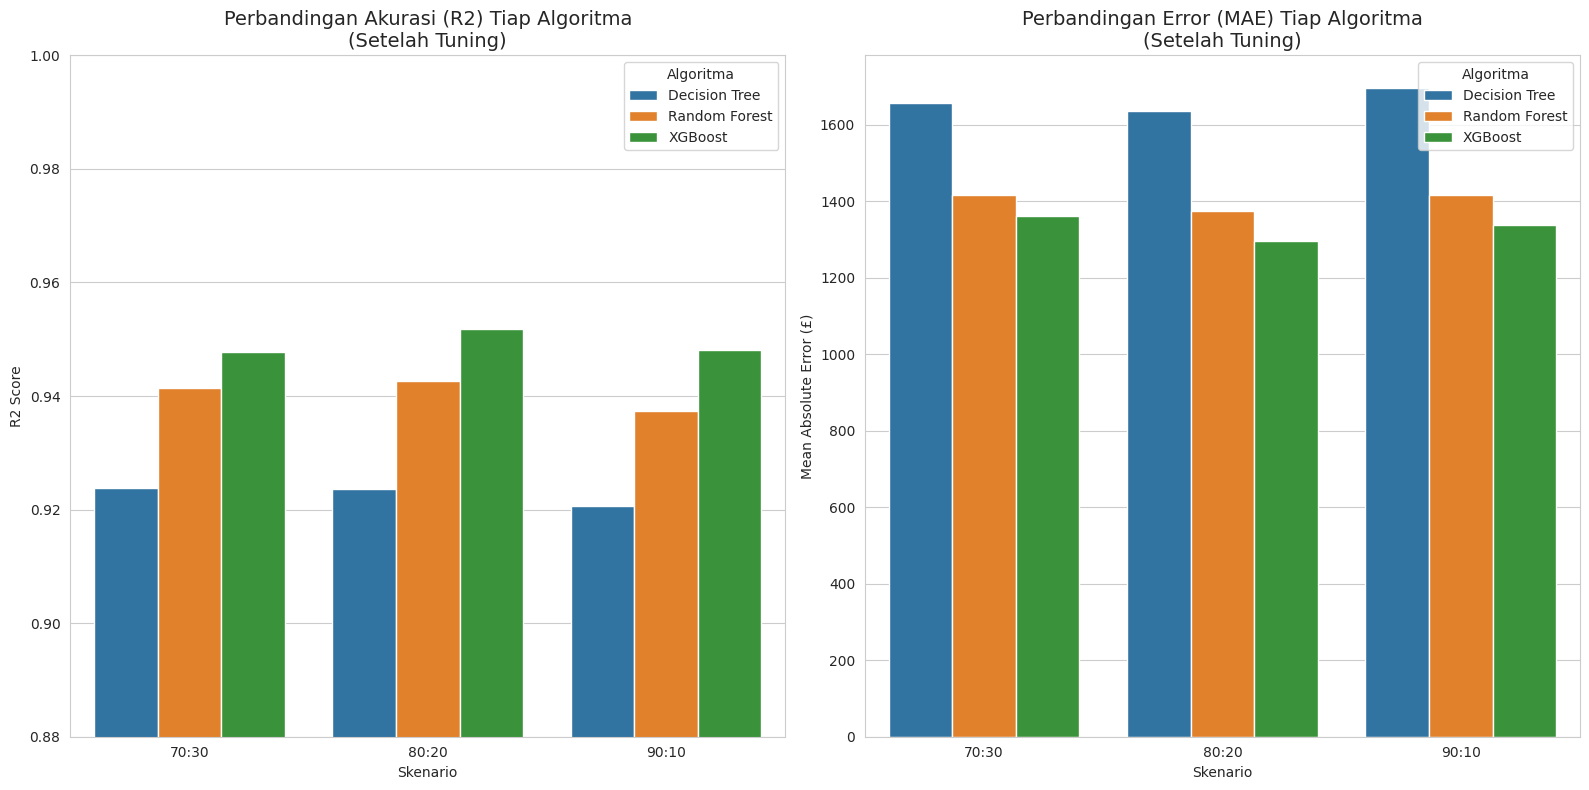


RATA-RATA AKURASI (R2) BERDASARKAN DATA SPLITTING
Skenario
80:20   0.9365
70:30   0.9346
90:10   0.9323
Name: R2, dtype: float64

Menyimpan model final...
BERHASIL: 'model_bmw.pkl', 'scaler_bmw.pkl', dan 'columns_bmw.pkl' telah disimpan.


In [ ]:
full_report = pd.concat([report_before, report_after], ignore_index=True)

model_comparison_table = full_report.pivot_table(
    index=['Skenario', 'Algoritma'],
    columns='Status',
    values=['R2', 'MAE']
).swaplevel(0, 1, axis=1).sort_index(axis=1)

print("\n" + "="*85)
print("TABEL PERBANDINGAN PERFORMA: AKURASI (R2) & ERROR (MAE)")
print("="*85)
pd.options.display.float_format = '{:.4f}'.format
print(model_comparison_table)

plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

plt.subplot(1, 2, 1)
sns.barplot(x='Skenario', y='R2', hue='Algoritma', data=full_report[full_report['Status'] == 'After Tuning'])
plt.title('Perbandingan Akurasi (R2) Tiap Algoritma\n(Setelah Tuning)', fontsize=14)
plt.ylim(0.88, 1.0)
plt.ylabel('R2 Score')

plt.subplot(1, 2, 2)
sns.barplot(x='Skenario', y='MAE', hue='Algoritma', data=full_report[full_report['Status'] == 'After Tuning'])
plt.title('Perbandingan Error (MAE) Tiap Algoritma\n(Setelah Tuning)', fontsize=14)
plt.ylabel('Mean Absolute Error (£)')

plt.tight_layout()
plt.show()

print("\n" + "="*85)
print("RATA-RATA AKURASI (R2) BERDASARKAN DATA SPLITTING")
print("="*85)
splitting_analysis = full_report.groupby('Skenario')['R2'].mean().sort_values(ascending=False)
print(splitting_analysis)

import joblib

print("\nMenyimpan model final...")

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X, y, test_size=0.1, random_state=42)

scaler_final = RobustScaler()
X_train_final_sc = scaler_final.fit_transform(X_train_f)

best_xgb_model = XGBRegressor(**search.best_params_, random_state=42)
best_xgb_model.fit(X_train_final_sc, y_train_f)

joblib.dump(best_xgb_model, 'model_bmw.pkl')
joblib.dump(scaler_final, 'scaler_bmw.pkl')
joblib.dump(X.columns.tolist(), 'columns_bmw.pkl')

print("="*85)
print("BERHASIL: 'model_bmw.pkl', 'scaler_bmw.pkl', dan 'columns_bmw.pkl' telah disimpan.")
print("="*85)

TABEL PERBANDINGAN PERFORMA: AKURASI (R2) & ERROR (MAE)


Status                 After Tuning        Before Tuning       
                                MAE     R2           MAE     R2
Skenario Algoritma                                             
70:30    Decision Tree    1656.5290 0.9238     1804.9071 0.9060
         Random Forest    1416.6007 0.9415     1432.5144 0.9390
         XGBoost          1362.1640 0.9478     1341.6082 0.9492
80:20    Decision Tree    1635.4697 0.9236     1768.2973 0.9086
         Random Forest    1376.0490 0.9427     1388.9295 0.9409
         XGBoost          1296.3904 0.9518     1332.7594 0.9514
90:10    Decision Tree    1697.0414 0.9206     1769.0045 0.9023
         Random Forest    1416.7117 0.9373     1431.0345 0.9372
         XGBoost          1338.2356 0.9481     1357.8172 0.9480

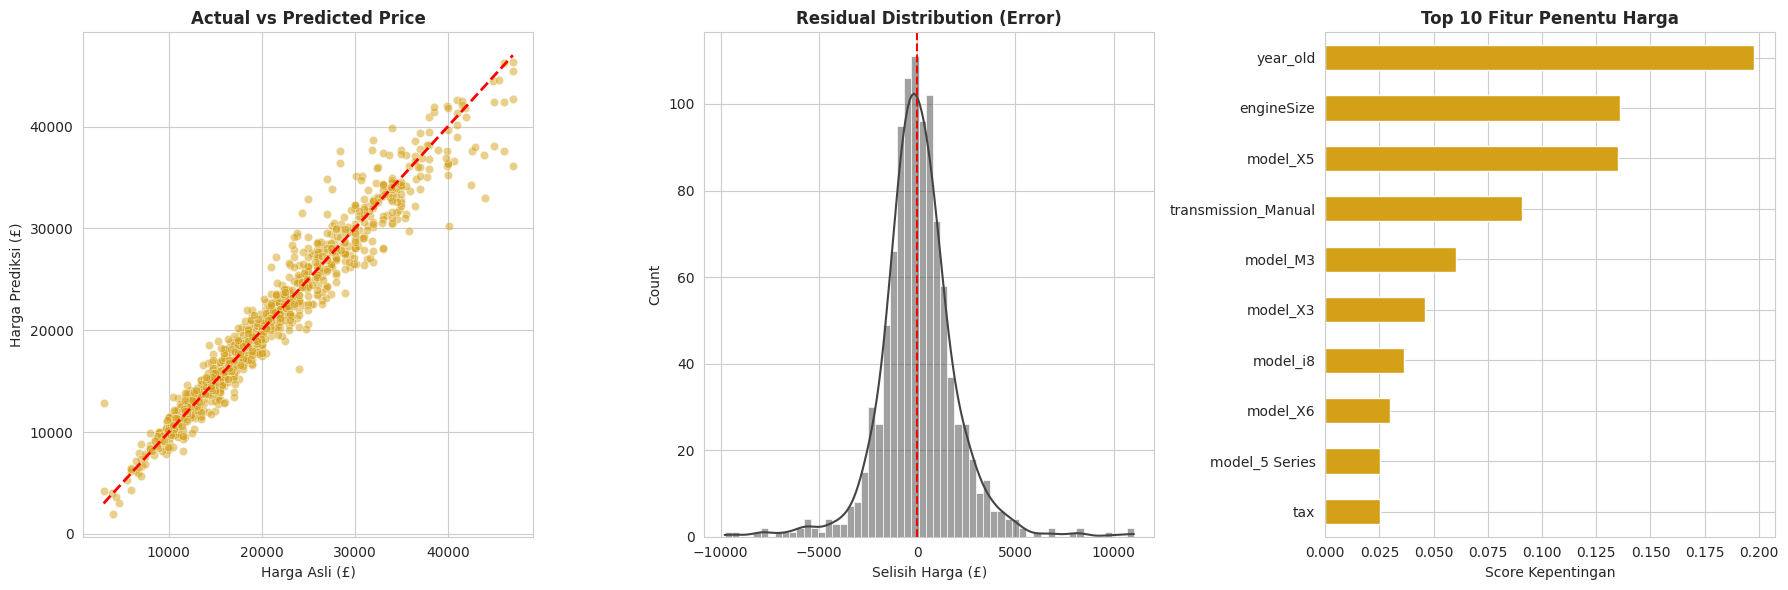


MEMULAI PROSES PENYIMPANAN MODEL PRODUKSI
BERHASIL: 'model_bmw_final.pkl' telah dilatih dengan 100% data dan siap digunakan.


In [ ]:
import joblib

# 1. Menggabungkan Laporan Performa (Before & After Tuning)
full_report = pd.concat([report_before, report_after], ignore_index=True)

# 2. Tabel Perbandingan Strategis
model_comparison_table = full_report.pivot_table(
    index=['Skenario', 'Algoritma'],
    columns='Status',
    values=['R2', 'MAE']
).swaplevel(0, 1, axis=1).sort_index(axis=1)

print("="*85)
print("TABEL PERBANDINGAN PERFORMA: AKURASI (R2) & ERROR (MAE)")
print("="*85)
pd.options.display.float_format = '{:.4f}'.format
display(model_comparison_table)

# 3. ANALISIS RESIDUAL (Melihat Kualitas Prediksi)
# Kita gunakan model terbaik hasil tuning untuk analisis ini
X_test_final_sc = scaler.transform(X_test) # Menggunakan X_test dari loop terakhir
y_pred_final = best_model.predict(X_test_final_sc)

y_true_price = np.expm1(y_test)
y_pred_price = np.expm1(y_pred_final)
residuals = y_true_price - y_pred_price

plt.figure(figsize=(18, 6))

# Plot A: Actual vs Predicted
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_true_price, y=y_pred_price, alpha=0.5, color='#D4A017')
plt.plot([y_true_price.min(), y_true_price.max()], [y_true_price.min(), y_true_price.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Price', fontsize=12, fontweight='bold')
plt.xlabel('Harga Asli (£)')
plt.ylabel('Harga Prediksi (£)')

# Plot B: Distribusi Error (Residuals)
plt.subplot(1, 3, 2)
sns.histplot(residuals, kde=True, color='#444444')
plt.axvline(x=0, color='r', linestyle='--')
plt.title('Residual Distribution (Error)', fontsize=12, fontweight='bold')
plt.xlabel('Selisih Harga (£)')

# Plot C: Feature Importance (10 Besar)
plt.subplot(1, 3, 3)
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind='barh', color='#D4A017')
plt.title('Top 10 Fitur Penentu Harga', fontsize=12, fontweight='bold')
plt.xlabel('Score Kepentingan')

plt.tight_layout()
plt.show()

# 4. FINALISASI: Retraining dengan 100% Data untuk Produksi
print("\n" + "="*85)
print("MEMULAI PROSES PENYIMPANAN MODEL PRODUKSI")
print("="*85)

# Melatih ulang menggunakan seluruh dataset (X dan y) agar pengalaman model maksimal
scaler_production = RobustScaler()
X_full_sc = scaler_production.fit_transform(X)

# Menggunakan parameter terbaik dari hasil Tuning terakhir
final_model_prod = XGBRegressor(**search.best_params_, random_state=42)
final_model_prod.fit(X_full_sc, y)

# Menyimpan File Artifact
joblib.dump(final_model_prod, 'model_bmw_final.pkl')
joblib.dump(scaler_production, 'scaler_bmw_final.pkl')
joblib.dump(X.columns.tolist(), 'columns_bmw_final.pkl')

print("BERHASIL: 'model_bmw_final.pkl' telah dilatih dengan 100% data dan siap digunakan.")
print("="*85)

In [ ]:
import joblib
import pandas as pd
import numpy as np

# 1. Load Model, Scaler, dan Daftar Kolom yang sudah disimpan
model_loaded = joblib.load('model_bmw_final.pkl')
scaler_loaded = joblib.load('scaler_bmw_final.pkl')
columns_loaded = joblib.load('columns_bmw_final.pkl')

# 2. INPUT DATA BARU (Simulasi data dari User/Aplikasi)
# Misal: Kita ingin cek harga BMW Seri 3, Tahun 2017, Matic, Diesel, 30rb miles, Mesin 2.0
data_input = {
    'model': '3 Series',
    'transmission': 'Automatic',
    'fuelType': 'Diesel',
    'tax': 145,
    'mpg': 55.4,
    'engineSize': 2.0,
    'year': 2017,
    'mileage': 30000
}

# 3. PREPROCESSING DATA INPUT (Harus sama dengan langkah Tahap 6)
# A. Feature Engineering
year_old = 2020 - data_input['year']
mileage_log = np.log1p(data_input['mileage'])

# B. Buat DataFrame awal
df_input = pd.DataFrame([[data_input['tax'], data_input['mpg'], data_input['engineSize'], year_old, mileage_log]],
                        columns=['tax', 'mpg', 'engineSize', 'year_old', 'mileage_log'])

# C. One-Hot Encoding (Menyesuaikan dengan kolom saat Training)
# Kita buat DataFrame kosong dengan kolom yang sama dengan saat training
df_inference = pd.DataFrame(columns=columns_loaded)

# Isi data numerik yang sudah ada
for col in df_input.columns:
    df_inference.loc[0, col] = df_input.loc[0, col]

# Isi data kategorikal (Encoding Manual)
# Set semua kolom kategori ke 0 dulu
model_col = 'model_' + data_input['model']
trans_col = 'transmission_' + data_input['transmission']
fuel_col = 'fuelType_' + data_input['fuelType']

# Jika kolom tersebut ada di daftar kolom training, set ke 1
for c in [model_col, trans_col, fuel_col]:
    if c in columns_loaded:
        df_inference.loc[0, c] = 1

# Isi kolom kategori lainnya yang tidak terpilih dengan 0
df_inference.fillna(0, inplace=True)

# 4. SCALING & PREDICTION
df_inference_sc = scaler_loaded.transform(df_inference)
prediction_log = model_loaded.predict(df_inference_sc)

# Balikkan dari skala Log ke Harga Asli (£)
final_price = np.expm1(prediction_log)[0]

print("="*60)
print("HASIL PREDIKSI HARGA MOBIL")
print("="*60)
print(f"Spesifikasi: BMW {data_input['model']} ({data_input['year']})")
print(f"Transmisi  : {data_input['transmission']}")
print(f"Bahan Bakar: {data_input['fuelType']}")
print(f"Mesin      : {data_input['engineSize']}L")
print("-" * 60)
print(f"ESTIMASI HARGA JUAL: £{final_price:,.2f}")
print("="*60)

HASIL PREDIKSI HARGA MOBIL
Spesifikasi: BMW 3 Series (2017)
Transmisi  : Automatic
Bahan Bakar: Diesel
Mesin      : 2.0L
------------------------------------------------------------
ESTIMASI HARGA JUAL: £17,767.85


/tmp/ipykernel_51011/787114018.py:52: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_inference.fillna(0, inplace=True)
